In [33]:
# !pip install rosbags 

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from rosbags.highlevel import AnyReader
from rosbags.typesys import get_types_from_msg
from rosbags.typesys import Stores, get_typestore
from pathlib import Path

# from mpl_toolkits.mplot3d import Axes3D

typestore = get_typestore(Stores.ROS2_HUMBLE)

msg_file_path = Path("/home/developer/ros2_ws/src/cf_control_msgs/msg/ThrustAndTorque.msg")
msg_text = msg_file_path.read_text()
msg_type_name = "cf_control_msgs/msg/ThrustAndTorque"

custom_types = get_types_from_msg(msg_text, msg_type_name)
typestore.register(custom_types)

In [35]:
bag_path = '/home/developer/ros2_ws/src/rosbag2_2026_06_09-17_20_15/rosbag2_2026_06_09-17_20_15_0.db3' 

target_topics = ['/crazyflie/ActualState', '/cf_control/control_command']
trajectory_waypoints = '/home/developer/ros2_ws/src/trajectory/trajectory_examples/screw.csv'

In [36]:
extracted_data = {topic: [] for topic in target_topics}

with AnyReader([Path(bag_path)], default_typestore=typestore) as reader:

    connections = [x for x in reader.connections if x.topic in target_topics]

    if not connections:
        print(f"Nie znaleziono żadnego z podanych tematów {target_topics} w wybranym rosbagu.")
    
    for connection, timestamp, rawdata in reader.messages(connections=connections):
        msg = reader.deserialize(rawdata, connection.msgtype)
        if msg is None:
            continue
            
        topic_name = connection.topic
        
        if topic_name == target_topics[0]:
            data_row = {
                "timestamp": timestamp,
                "pose_x": msg.pose.pose.position.x,
                "pose_y": msg.pose.pose.position.y,
                "pose_z": msg.pose.pose.position.z,
                "vel_x": msg.twist.twist.linear.x,
                "vel_y": msg.twist.twist.linear.y,
                "vel_z": msg.twist.twist.linear.z,
                "ori_qx": msg.pose.pose.orientation.x,
                "ori_qy": msg.pose.pose.orientation.y,
                "ori_qz": msg.pose.pose.orientation.z,
                "ori_qw": msg.pose.pose.orientation.w,
                "ang_vel_x": msg.twist.twist.angular.x,
                "ang_vel_y": msg.twist.twist.angular.y,
                "ang_vel_z": msg.twist.twist.angular.z
            }
            extracted_data[topic_name].append(data_row)
            
        elif topic_name == target_topics[1]:
            # ROZBICIE WEKTORA TORQUE NA SKŁADOWE LICZBOWE
            data_row = {
                "timestamp": timestamp,
                "thrust": msg.collective_thrust,  
                "torque_x": msg.torque.x,
                "torque_y": msg.torque.y,
                "torque_z": msg.torque.z
            }
            extracted_data[topic_name].append(data_row)

# --- SAVE TO CSV ---

dataframes_to_combine = []

for topic, rows in extracted_data.items():
    if rows:
        df = pd.DataFrame(rows)
        df.set_index('timestamp', inplace=True)
        safe_topic_name = topic.replace("/", "_").strip("_")
        df = df.add_prefix(f"{safe_topic_name}_")
        
        dataframes_to_combine.append(df)

if dataframes_to_combine:
    combined_df = pd.concat(dataframes_to_combine, axis=1, join='outer')
    combined_df.sort_index(inplace=True)
    combined_df.reset_index(inplace=True)
    
    output_combined_csv = "/home/developer/ros2_ws/src/rosbag2_2026_06_09-17_20_15/rosbag_data.csv"
    combined_df.to_csv(output_combined_csv, index=False)
    
    print(f"Sukces! Wszystkie topiki zostały połączone i zapisane do: {output_combined_csv}")
    print(f"Łączna liczba wierszy (unikalnych znaczników czasu): {combined_df.shape[0]}")
else:
    print("Brak danych z jakiegokolwiek topiku. Plik CSV nie został utworzony.")

# --- Twój dotychczasowy kod dla waypointów ---
waypoints_df = pd.read_csv(trajectory_waypoints, skiprows=1)
waypoints_np = waypoints_df.values
print(f'Zaimportowano {waypoints_np.shape[0]} waypointów.')

Sukces! Wszystkie topiki zostały połączone i zapisane do: /home/developer/ros2_ws/src/rosbag2_2026_06_09-17_20_15/rosbag_data.csv
Łączna liczba wierszy (unikalnych znaczników czasu): 927
Zaimportowano 59 waypointów.


In [37]:
data_file_csv = '/home/developer/ros2_ws/src/rosbag2_2026_06_09-17_20_15/rosbag_data.csv'

data_df = pd.read_csv(data_file_csv)


pose_cols = [
    'crazyflie_ActualState_pose_x', 
    'crazyflie_ActualState_pose_y', 
    'crazyflie_ActualState_pose_z'
]

vel_cols = [
    'crazyflie_ActualState_vel_x', 
    'crazyflie_ActualState_vel_y', 
    'crazyflie_ActualState_vel_z'
]

ori_cols = [
    'crazyflie_ActualState_ori_qx', 
    'crazyflie_ActualState_ori_qy', 
    'crazyflie_ActualState_ori_qz', 
    'crazyflie_ActualState_ori_qw'
]

ang_vel_cols = [
    'crazyflie_ActualState_ang_vel_x', 
    'crazyflie_ActualState_ang_vel_y', 
    'crazyflie_ActualState_ang_vel_z'
]


actual_state_df = data_df[['timestamp'] + pose_cols + vel_cols + ori_cols + ang_vel_cols].dropna(subset=pose_cols)


timestamp_pose_np = actual_state_df['timestamp'].values
pose_np           = actual_state_df[pose_cols].values
velocity_np       = actual_state_df[vel_cols].values
orientation_np    = actual_state_df[ori_cols].values
ang_velocity_np   = actual_state_df[ang_vel_cols].values


control_cols = [
    'cf_control_control_command_thrust',
    'cf_control_control_command_torque_x',
    'cf_control_control_command_torque_y',
    'cf_control_control_command_torque_z'
]

control_df = data_df[['timestamp'] + control_cols].dropna(subset=control_cols)

timestamp_control_np = control_df['timestamp'].values
thrust_np            = control_df['cf_control_control_command_thrust'].values
torque_np            = control_df[['cf_control_control_command_torque_x', 
                                   'cf_control_control_command_torque_y', 
                                   'cf_control_control_command_torque_z']].values


print(f"Pomyślnie wyodrębniono dane:")
print(f" -> Próbki stanu (ActualState): {pose_np.shape[0]}")
print(f" -> Próbki sterowania (Control):  {thrust_np.shape[0]}")

Pomyślnie wyodrębniono dane:
 -> Próbki stanu (ActualState): 542
 -> Próbki sterowania (Control):  385


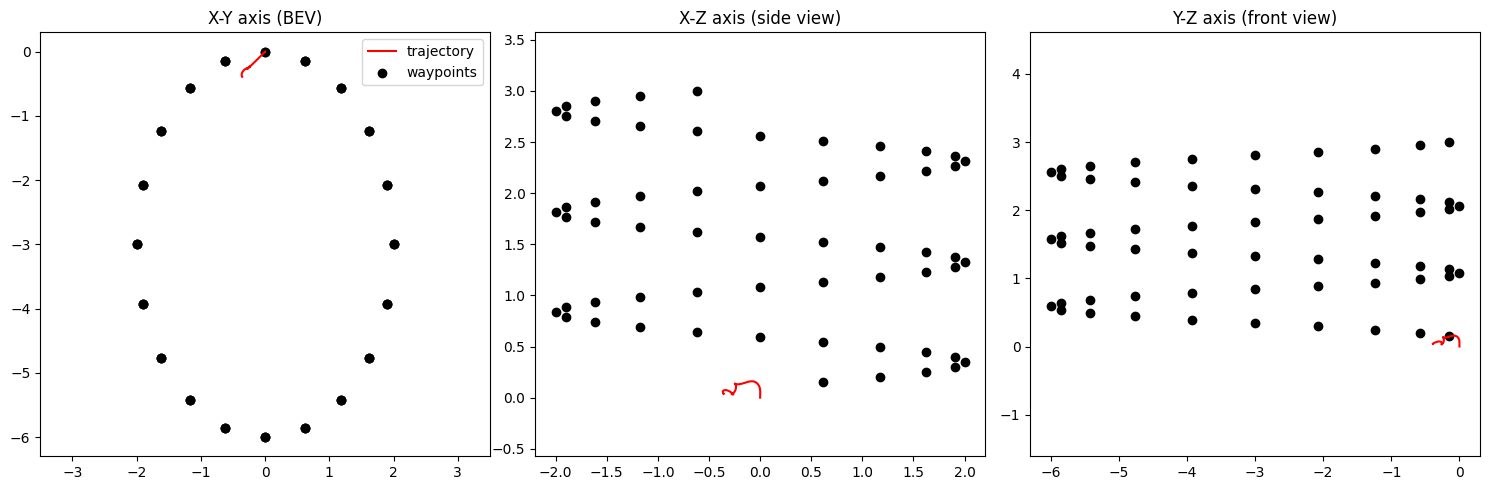

In [38]:
samples_num = pose_np.shape[0]

start = int(0 * samples_num)
end = int(1 * samples_num)

trajectory_x, trajectory_y, trajectory_z = pose_np[start:end, 0], pose_np[start:end, 1], pose_np[start:end, 2]
waypints_x, waypints_y, waypints_z = waypoints_np[:, 0], waypoints_np[:, 1], waypoints_np[:, 2]


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

#  (X - Y)
ax1.plot(trajectory_x, trajectory_y, color='red', label='trajectory')
ax1.scatter(waypints_x, waypints_y, color='black', label='waypoints')
ax1.set_title("X-Y axis (BEV)")
ax1.legend()
ax1.axis('equal') 

#  (X - Z)
ax2.plot(trajectory_x, trajectory_z, color='red')
ax2.scatter(waypints_x, waypints_z, color='black')
ax2.set_title("X-Z axis (side view)")
ax2.axis('equal')

#  (Y - Z)
ax3.plot(trajectory_y, trajectory_z, color='red')
ax3.scatter(waypints_y, waypints_z, color='black')
ax3.set_title("Y-Z axis (front view)")
ax3.axis('equal')

plt.tight_layout()
plt.show()

In [39]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=trajectory_x, 
    y=trajectory_y, 
    z=trajectory_z,
    mode='lines',
    name='Trajektoria drona',
    line=dict(color='blue', width=4)
))

fig.add_trace(go.Scatter3d(
    x=waypints_x, 
    y=waypints_y, 
    z=waypints_z,
    mode='markers',
    name='Waypointy',
    marker=dict(color='black', size=4)
))

fig.update_layout(
    title="Drone trajectory",
    scene=dict(
        xaxis_title=' X (m)',
        yaxis_title=' Y (m)',
        zaxis_title=' Z (m)'
    ),
    width=900,
    height=700
)

fig.show()